# Radar Products with Coiled (Map-Reduce)

Optimized for 75-worker cluster with `chunks={'vcp_time': 50}`.

**Chunk math:**
- Stored: `vcp_time=1` → ~5.3 MB each
- Logical: `vcp_time=50` → 50 × 5.3 = **~265 MB** per chunk
- Good parallelism: even small VCPs get 47+ chunks → all workers busy

**Products computed (spatial):**
- Max/mean reflectivity, QPE total
- Echo frequencies: >20, >40, >60, >65 dBZ
- Dual-pol hail frequency

**Run all cells in order. Restart kernel if changing chunk size.**

In [1]:
import coiled
import icechunk as ic
import numpy as np
import pandas as pd
import xarray as xr
from dask.distributed import LocalCluster
from pathlib import Path

from raw2zarr.transform import map_reduce

In [2]:
import boto3

session = boto3.Session(profile_name="nexrad-realtime")
credentials = session.get_credentials()

access_key = credentials.access_key
secret_key = credentials.secret_key
print("Credentials loaded")

Credentials loaded


In [3]:
# coiled.create_software_environment(                                                                                                                                                                                   
#   name="raw2zarr-env",                                                                                                                                                                                              
#   pip="../requirements.txt",                                                                                                                                                                                        
#   force_rebuild=True,                                                                                                                                                                                               
#   use_uv_installer=False,  # Use pip instead of uv                                                                                                                                                                  
# )

In [4]:
# Icechunk storage config
storage = ic.s3_storage(
    bucket='nexrad-dtree',
    prefix='KLOT',
    endpoint_url=None,
    access_key_id=access_key,
    secret_access_key=secret_key,
    force_path_style=False,
    region='us-east-1',
)

# Config dict for workers (they use env vars for credentials)
storage_config = {
    "bucket": "nexrad-dtree",
    "prefix": "KLOT",
    "region": "us-east-1",
}

print(f"Storage: s3://{storage_config['bucket']}/{storage_config['prefix']}")

Storage: s3://nexrad-dtree/KLOT


In [5]:
%%time
# Open repo with optimized time chunks for 75-worker cluster
# 
# Stored chunks: vcp_time=1, azimuth=720, range=1832 → ~5.3 MB each
# With vcp_time=50: 50 × 5.3 MB = ~265 MB per logical chunk
# 
# This gives good parallelism even for small VCPs:
#   VCP-11 (2.3k timesteps) → 47 chunks → 47 workers busy
#   VCP-31 (71k timesteps) → 1420 chunks → excellent parallelism

repo = ic.Repository.open(storage)
session_ic = repo.readonly_session("main")

dtree = xr.open_datatree(
    session_ic.store,
    zarr_format=3,
    consolidated=False,
    chunks={'vcp_time': 50},  # ~265 MB per chunk, good parallelism
    engine="zarr",
)

# Extract VCP names
vcp_names = [g.split("/")[1] for g in dtree.groups if g.startswith("/VCP-")]
vcp_names = sorted(list(set(vcp_names)))
print(f"Found {len(vcp_names)} VCPs: {vcp_names}")

# Show chunk info
print(f"\nChunk configuration: vcp_time=50 (~265 MB per chunk)")
for vcp in vcp_names:
    n_times = dtree[f"{vcp}/sweep_0"].ds.sizes.get("vcp_time", 0)
    n_chunks = (n_times + 49) // 50
    print(f"  {vcp}: {n_times:,} timesteps → {n_chunks} chunks")

Found 7 VCPs: ['VCP-11', 'VCP-12', 'VCP-21', 'VCP-211', 'VCP-212', 'VCP-31', 'VCP-32']

Chunk configuration: vcp_time=50 (~265 MB per chunk)
  VCP-11: 2,335 timesteps → 47 chunks
  VCP-12: 33,577 timesteps → 672 chunks
  VCP-21: 54,886 timesteps → 1098 chunks
  VCP-211: 3 timesteps → 1 chunks
  VCP-212: 40,532 timesteps → 811 chunks
  VCP-31: 71,025 timesteps → 1421 chunks
  VCP-32: 12,617 timesteps → 253 chunks
CPU times: user 4.64 s, sys: 733 ms, total: 5.37 s
Wall time: 9.39 s


In [6]:
# Start Coiled cluster
# With distributed chunk processing, ALL workers will be busy!

local = False  # Set True for local testing

if local:
    print("Using local cluster")
    cluster = LocalCluster(
        n_workers=4,
        threads_per_worker=1,
        memory_limit="4GB",
    )
    client = cluster.get_client()
else:
    print("Starting Coiled cluster (75 workers - all will be used!)...")
    cluster = coiled.Cluster(
        software="raw2zarr-env",
        n_workers=75,  # All workers process chunks in parallel
        worker_cpu=4,
        worker_memory="16 GiB",
        region="us-east-1",
        idle_timeout="30 minutes",
        compute_purchase_option="spot_with_fallback",
        environ={
            "AWS_ACCESS_KEY_ID": access_key,
            "AWS_SECRET_ACCESS_KEY": secret_key,
            "AWS_DEFAULT_REGION": "us-east-1",
        },
    )
    client = cluster.get_client()

print(f"Dashboard: {client.dashboard_link}")
print(f"Workers: {len(client.ncores())} with {sum(client.ncores().values())} total cores")
client

Starting Coiled cluster (75 workers - all will be used!)...


Output()

Dashboard: https://cluster-isyke.dask.host/laNbS7XoUxvxdYc4/status
Workers: 68 with 272 total cores


<Client: 'tls://10.0.52.22:8786' processes=68 threads=272, memory=0.97 TiB>

In [7]:
%%time
# =============================================================================
# COMPUTE SPATIAL PRODUCTS - optimized for 75 workers
# =============================================================================

def radar_product_partials(ds):
    """
    Compute spatial partials.
    
    With chunks={'vcp_time': 50} (~265 MB), all 75 workers stay busy.
    """
    dbzh = ds["DBZH"]
    z_lin = 10 ** (dbzh / 10)
    time_dim = "vcp_time"
    
    partials = {
        "max_z_max": dbzh.max(time_dim),
        "z_lin_sum": z_lin.sum(time_dim),
        "z_lin_count": z_lin.count(time_dim),
        "qpe_sum": ((z_lin / 200) ** (1 / 1.6) * (5 / 60)).sum(time_dim),
        "echo_20_sum": (dbzh > 20).sum(time_dim),
        "echo_40_sum": (dbzh > 40).sum(time_dim),
        "echo_60_sum": (dbzh > 60).sum(time_dim),
        "severe_65_sum": (dbzh > 65).sum(time_dim),
        "total_count": dbzh.count(time_dim),
    }
    
    # Dual-pol hail
    if "RHOHV" in ds and "ZDR" in ds:
        hail_dualpol = (dbzh > 50) & (ds["RHOHV"] < 0.92) & (ds["ZDR"] < 1.0)
        partials["hail_dualpol_sum"] = hail_dualpol.sum(time_dim)
    
    return partials


print(f"Processing {len(vcp_names)} VCPs with {len(client.ncores())} workers...")
print(f"Chunks: vcp_time=50 (~265 MB each)")

partials = map_reduce(
    radar_product_partials, 
    dtree, 
    "sweep_0", 
    client=client, 
    verbose=True
)

print(f"\nPartials computed: {list(partials.keys())}")

Processing 7 VCPs with 68 workers...
Chunks: vcp_time=50 (~265 MB each)
Map-reduce: 7 VCPs, 68 workers
  [1/7] VCP-11: 2335 timesteps
  [2/7] VCP-12: 33577 timesteps
  [3/7] VCP-21: 54886 timesteps
  [4/7] VCP-211: 3 timesteps
  [5/7] VCP-212: 40532 timesteps
  [6/7] VCP-31: 71025 timesteps
  [7/7] VCP-32: 12617 timesteps
  Combining 7 partial results...

Partials computed: ['max_z_max', 'z_lin_sum', 'z_lin_count', 'qpe_sum', 'echo_20_sum', 'echo_40_sum', 'echo_60_sum', 'severe_65_sum', 'total_count', 'hail_dualpol_sum']
CPU times: user 10.4 s, sys: 1.72 s, total: 12.2 s
Wall time: 4min 6s


In [8]:
# =============================================================================
# COMPUTE FINAL PRODUCTS FROM PARTIALS (spatial only)
# =============================================================================

products = {}

# === SPATIAL PRODUCTS (azimuth × range) ===
products["max_reflectivity"] = partials["max_z_max"]

mean_linear = partials["z_lin_sum"] / partials["z_lin_count"]
products["mean_reflectivity"] = 10 * np.log10(mean_linear)

products["qpe_total"] = partials["qpe_sum"]

total = partials["total_count"]
products["echo_freq_20dBZ"] = (partials["echo_20_sum"] / total) * 100
products["echo_freq_40dBZ"] = (partials["echo_40_sum"] / total) * 100
products["hail_freq_60dBZ"] = (partials["echo_60_sum"] / total) * 100
products["severe_hail_65dBZ"] = (partials["severe_65_sum"] / total) * 100

if "hail_dualpol_sum" in partials:
    products["hail_freq_dualpol"] = (partials["hail_dualpol_sum"] / total) * 100

print("Final products (spatial only):")
print("-" * 40)
for name, data in products.items():
    print(f"  {name}: {data.shape}")

Final products (spatial only):
----------------------------------------
  max_reflectivity: (720, 1832)
  mean_reflectivity: (720, 1832)
  qpe_total: (720, 1832)
  echo_freq_20dBZ: (720, 1832)
  echo_freq_40dBZ: (720, 1832)
  hail_freq_60dBZ: (720, 1832)
  severe_hail_65dBZ: (720, 1832)
  hail_freq_dualpol: (720, 1832)


In [9]:
# =============================================================================
# SAVE TO ZARR V3 WITH METADATA
# =============================================================================

output_store = Path("/home/alfonso-ladino/python/raw2zarr/zarr/products_KLOT_mapreduce.zarr")

# Combine all results into a Dataset
ds_products = xr.Dataset(products)

# Add global metadata
ds_products.attrs = {
    "title": "Radar Climatological Products (Spatial)",
    "source": f"KLOT NEXRAD ({storage_config['bucket']}/{storage_config['prefix']})",
    "created": str(pd.Timestamp.now()),
    "description": "Spatial products computed using map-reduce with larger time chunks",
    "conventions": "CF-1.8",
    "vcps_processed": ", ".join(vcp_names),
    "note": "Diurnal products excluded - use spatial chunking or more memory for those",
}

# Add units and descriptions
product_attrs = {
    "max_reflectivity": {"units": "dBZ", "long_name": "Maximum reflectivity"},
    "mean_reflectivity": {"units": "dBZ", "long_name": "Mean reflectivity (linear average)"},
    "qpe_total": {"units": "mm", "long_name": "Total rainfall accumulation"},
    "echo_freq_20dBZ": {"units": "%", "long_name": "Echo frequency >20 dBZ"},
    "echo_freq_40dBZ": {"units": "%", "long_name": "Convective frequency >40 dBZ"},
    "hail_freq_60dBZ": {"units": "%", "long_name": "Hail frequency >60 dBZ"},
    "severe_hail_65dBZ": {"units": "%", "long_name": "Severe hail frequency >65 dBZ"},
    "hail_freq_dualpol": {"units": "%", "long_name": "Hail frequency (dual-pol)"},
}

for var, attrs in product_attrs.items():
    if var in ds_products:
        ds_products[var].attrs.update(attrs)

print(ds_products)

# Save to Zarr v3 with consolidated metadata
print(f"\nSaving to {output_store}...")
ds_products.to_zarr(output_store, mode="w", zarr_format=3, consolidated=True)
print(f"Saved {len(ds_products.data_vars)} products to {output_store}")

<xarray.Dataset> Size: 137MB
Dimensions:            (azimuth: 720, range: 1832)
Coordinates: (12/14)
  * azimuth            (azimuth) float64 6kB 0.25 0.75 1.25 ... 359.2 359.8
  * range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
    alt                (azimuth, range) float64 11MB 249.8 252.1 ... 1.668e+04
    altitude           float64 8B 231.0
    crs_wkt            int64 8B 0
    lat                (azimuth, range) float64 11MB 41.62 41.63 ... 45.73 45.74
    ...                 ...
    latitude           float64 8B 41.6
    longitude          float64 8B -88.08
    x                  (azimuth, range) float64 11MB 9.271 10.36 ... -2.004e+03
    z                  (azimuth, range) float64 11MB 249.8 252.1 ... 1.668e+04
    y                  (azimuth, range) float64 11MB 2.125e+03 ... 4.592e+05
    time               (azimuth) datetime64[ns] 6kB 2015-01-01T00:09:35 ... 2...
Data variables:
    max_reflectivity   (azimuth, range) float32 5MB 51.5 54.5 56.5 ... 

/home/alfonso-ladino/python/raw2zarr/.venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Visualization

In [10]:
import matplotlib.pyplot as plt
import cmweather  # For radar colormaps

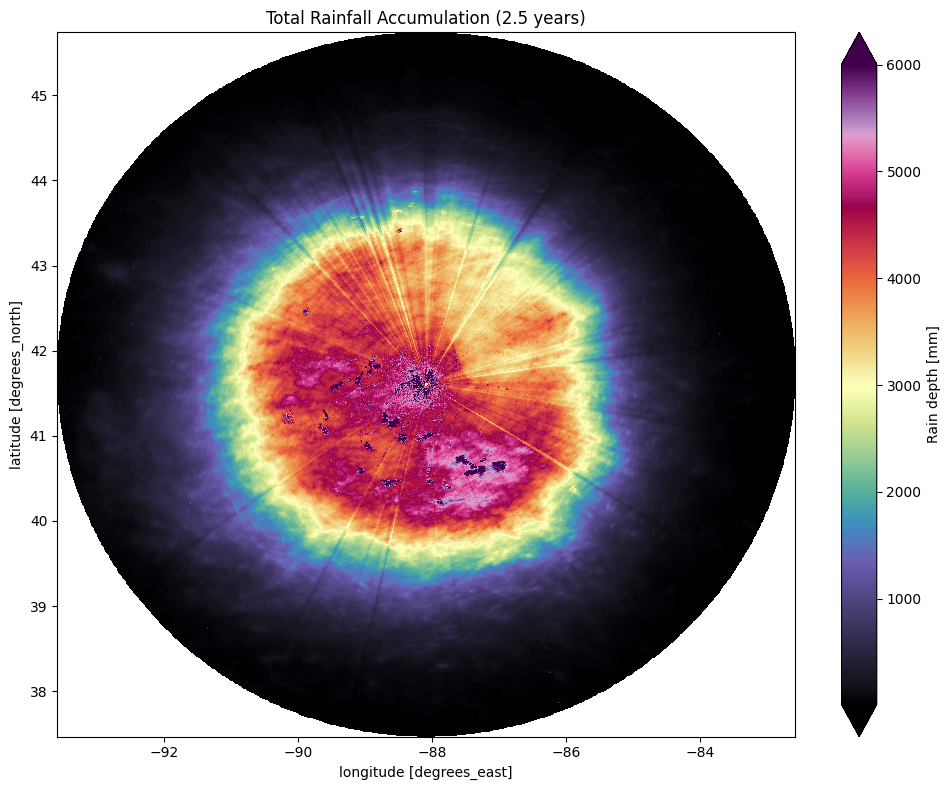

In [11]:
# QPE Total
fig, ax = plt.subplots(figsize=(10, 8))
products["qpe_total"].plot(
    x="lon", y="lat", cmap="ChaseSpectral", robust=True,
    cbar_kwargs={"label": "Rain depth [mm]"}, ax=ax
)
ax.set_title("Total Rainfall Accumulation (2.5 years)")
plt.tight_layout()

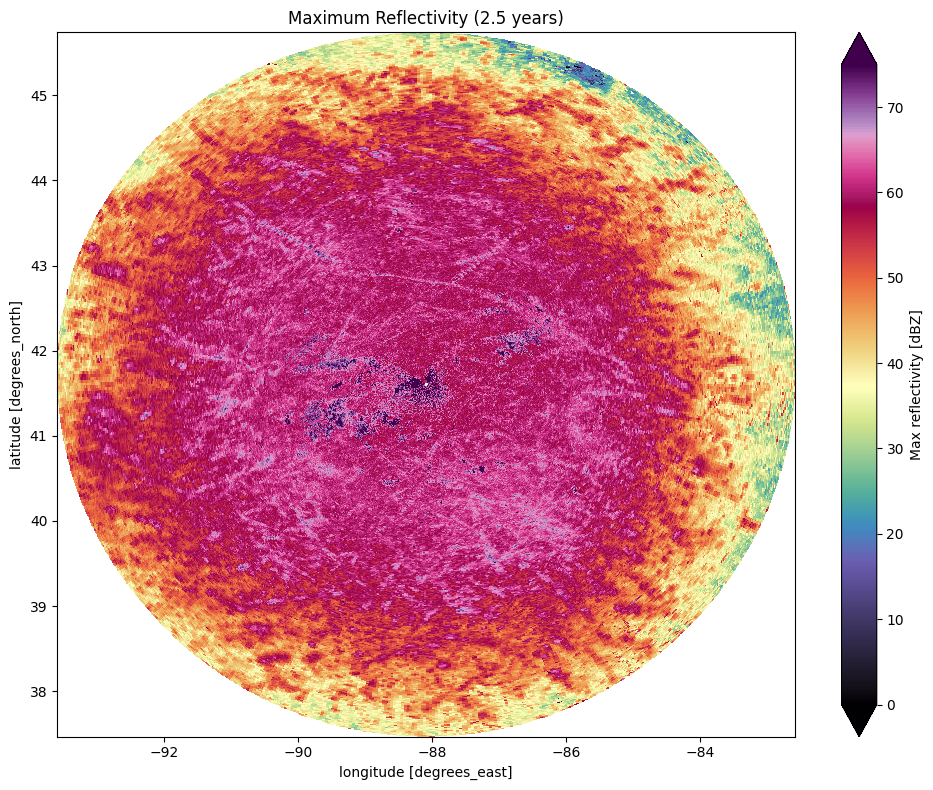

In [12]:
# Max Reflectivity
fig, ax = plt.subplots(figsize=(10, 8))
products["max_reflectivity"].plot(
    x="lon", y="lat", cmap="ChaseSpectral", vmin=0, vmax=75,
    cbar_kwargs={"label": "Max reflectivity [dBZ]"}, ax=ax
)
ax.set_title("Maximum Reflectivity (2.5 years)")
plt.tight_layout()

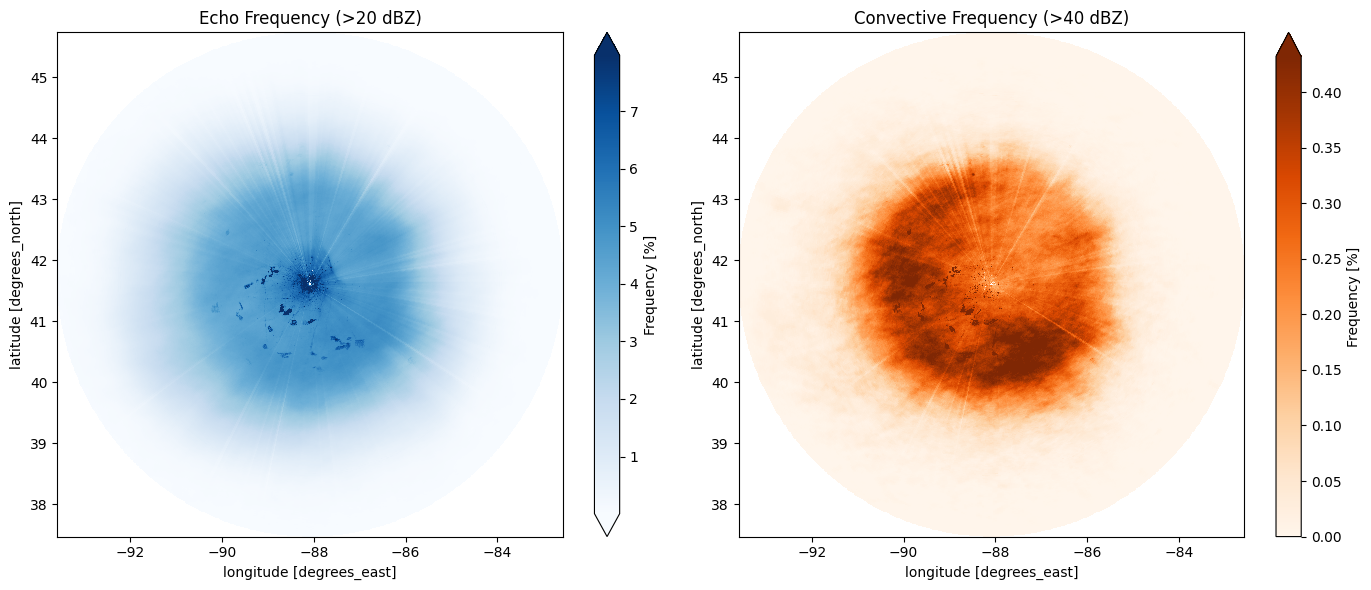

In [13]:
# Echo Frequency
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

products["echo_freq_20dBZ"].plot(
    x="lon", y="lat", cmap="Blues", robust=True,
    cbar_kwargs={"label": "Frequency [%]"}, ax=axes[0]
)
axes[0].set_title("Echo Frequency (>20 dBZ)")

products["echo_freq_40dBZ"].plot(
    x="lon", y="lat", cmap="Oranges", robust=True,
    cbar_kwargs={"label": "Frequency [%]"}, ax=axes[1]
)
axes[1].set_title("Convective Frequency (>40 dBZ)")

plt.tight_layout()

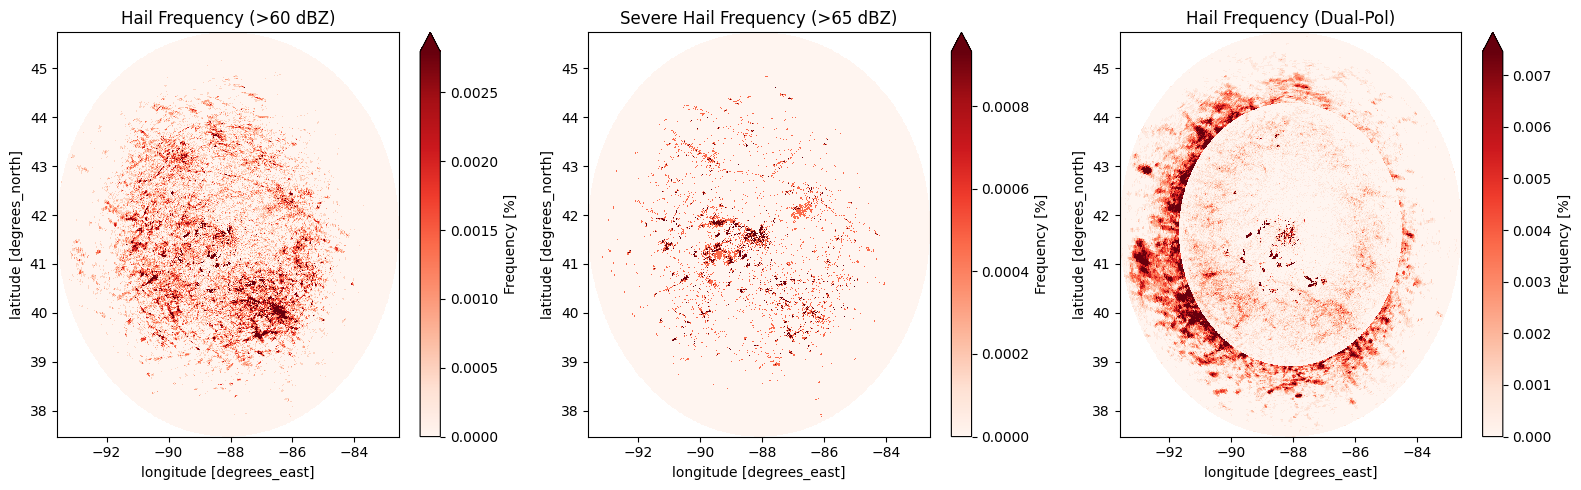

In [14]:
# Hail Frequency
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

products["hail_freq_60dBZ"].plot(
    x="lon", y="lat", cmap="Reds", robust=True,
    cbar_kwargs={"label": "Frequency [%]"}, ax=axes[0]
)
axes[0].set_title("Hail Frequency (>60 dBZ)")

products["severe_hail_65dBZ"].plot(
    x="lon", y="lat", cmap="Reds", robust=True,
    cbar_kwargs={"label": "Frequency [%]"}, ax=axes[1]
)
axes[1].set_title("Severe Hail Frequency (>65 dBZ)")

if "hail_freq_dualpol" in products:
    products["hail_freq_dualpol"].plot(
        x="lon", y="lat", cmap="Reds", robust=True,
        cbar_kwargs={"label": "Frequency [%]"}, ax=axes[2]
    )
    axes[2].set_title("Hail Frequency (Dual-Pol)")
else:
    axes[2].set_visible(False)

plt.tight_layout()

In [15]:
# Shutdown cluster when done to save money
# cluster.close()

## Load Saved Products (no cluster needed)

Use this code in a new notebook to reload and visualize products:

In [16]:
# # Load saved products (run in fresh notebook - no cluster needed)
# import xarray as xr
# from pathlib import Path
#
# store = Path("/home/alfonso-ladino/python/raw2zarr/zarr/products_KLOT_mapreduce.zarr")
#
# # Load entire dataset (consolidated metadata makes this fast)
# ds = xr.open_zarr(store, zarr_format=3, consolidated=True)
# print(ds)
#
# # Plot individual products
# ds["qpe_total"].plot(x="lon", y="lat", cmap="ChaseSpectral", robust=True)
# ds["max_reflectivity"].plot(x="lon", y="lat", cmap="ChaseSpectral", vmin=0, vmax=75)
#
# # Echo frequencies
# ds["echo_freq_40dBZ"].plot(x="lon", y="lat", cmap="Oranges", robust=True)